In [2]:
import numpy as np 
import torch 
import torch.nn as nn
import torch.nn.functional as F

In [3]:
sequence_length = 4
batch_size = 1
input_dim = 512
d_model = 512
x = torch.rand((batch_size, sequence_length, input_dim))


In [4]:
x.size()

torch.Size([1, 4, 512])

In [5]:
qkv_layer = nn.Linear(d_model, d_model * 3)

In [9]:
qkv = qkv_layer(x)

In [10]:
qkv.shape

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'QKV distribution')

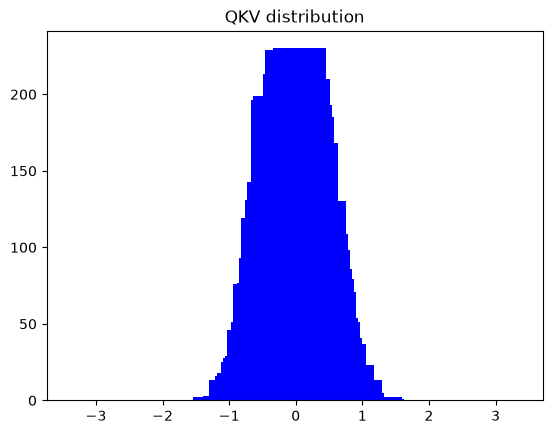

In [11]:
import matplotlib.pyplot as plt
y_val = torch.histc(qkv, bins=200, min=-3, max=3)
x_val = np.arange(-1, 1 , 0.01) * 3
plt.bar(x_val, y_val,align='center',color='blue')
plt.title('QKV distribution')

In [12]:
num_heads = 8
head_dim  = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [13]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [14]:
qkv = qkv.permute(0, 2, 1, 3)  # (batch_size, num_heads, sequence_length, 3 * head_dim)
qkv.shape

torch.Size([1, 8, 4, 192])

In [15]:
q,k,v = qkv.chunk(3, dim=-1)  # Split the last dimension into Q
q.shape, k.shape, v.shape

(torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]),
 torch.Size([1, 8, 4, 64]))

$$
\text{self attention} = softmax\left(\frac{Q \cdot K^T}{\sqrt{d_k}} + M\right)
$$

$$
\text{new V} = \text{self attention} \cdot V
$$

In [16]:
d_k = q.size(-1)
scaled = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(d_k)
scaled.shape

torch.Size([1, 8, 4, 4])